# Fairness Evaluation

## 1 Overview

The fairness of the Solace pipeline's components across the groups most pertinent to a multilingual healthcare staff is audited in this notebook. It assesses three factors: the MERaLiON speech-emotion model's performance across speaker sex, the Whisper transcription model's performance across the four supported languages, and the NLLB-200 translation model's performance.

The same metrics used elsewhere in the project are used to evaluate each component on held-out data: accuracy and macro-F1 for emotion, CER and WER for transcription, and chrF++ and BLEU for translation. The differences are summarised as gaps between the best and worst group. The notebook is also clear about what it cannot currently evaluate the demographic fairness of the text and vision models is noted as out of scope rather than presumed because they lack demographic identifiers. A responsible AI criterion for a tool that affects people's well-being is an honest map of where the system is and is not biased.

## 2 Importing Libraries

The toolchain required for the fairness audit is imported in this section, covering all three of the components being tested. For transcription, jiwer supplies character and word error rates; for translation, sacreBLEU supplies chrF++ and BLEU and for the emotion model, scikit-learn supplies accuracy and the macro precision/recall/F1. Pandas organises the per-group results, matplotlib creates the per-language bar charts, the Transformers classes load Whisper and NLLB-200, Torch provides the device and GPU, and the output folder and metric objects are built once in advance.

In [1]:
# remove all warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# import requried libraries
from pathlib import Path
import gc
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import torch
from jiwer import cer, wer
from sacrebleu.metrics import BLEU, CHRF
from sklearn.metrics import accuracy_score, f1_score,precision_score,recall_score
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, pipeline

In [3]:
# base directory
BASE_DIR = Path("../..").resolve()

In [4]:
# output directory
OUTPUT_DIR = (BASE_DIR/ "data" / "processed" / "fairness_evaluation")

In [5]:
# create folder
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

In [6]:
# set device to 0 if cuda available
DEVICE = (0 if torch.cuda.is_available() else -1)
TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# bleu metric
bleu_metric = BLEU()

In [8]:
# chrf metric
chrf_metric = CHRF(word_order=2)

In [9]:
# print statements
print("Device:", TORCH_DEVICE)
print("Output folder:", OUTPUT_DIR)

Device: cpu
Output folder: C:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP\data\processed\fairness_evaluation


The three audits transcription, translation, and emotion run under a single, consistent configuration when all metrics and model interfaces are gathered in one location, which allows their gap numbers to be comparable. The 800-clip transcription pass and the translation pass remain tractable when the GPU is chosen when it is available. The common text normalization that is necessary for fair error scoring is defined in the next section.

## 3 Text Normalisation

This section defines a single normalization function that collapses whitespace, performs Unicode NFKC normalisation, lowercases text, and substitutes spaces for punctuation. Before scoring, the identical function is used for each reference and prediction in all four languages and scripts.

In [10]:
# define normalise text
def normalise_text(text):
    # normalize the text
    text = unicodedata.normalize("NFKC",str(text)).lower()
    # compute text
    text = "".join(character if character.isalnum() or character.isspace() else " " for character in text)
    return " ".join(text.split()).strip()

The error rates are kept fair by applying the same normaliser to both references and predictions. Without this, a model would be penalised for harmless variations in punctuation, case, or Unicode form rather than for actual transcription or translation issues. Because the audit covers Latin, Han, and Tamil scripts, where multiple virtually identical characters have distinct code points, using NFKC is very important in this case. The first component can be audited once normalisation has been adjusted.

## 4 Whisper Language Fairness

The transcription fairness of the four supported languages is audited in this area. After loading the balanced FLEURS test set (200 clips per language), each clip is transcribed using Whisper-small pushed into the appropriate language. CER and WER are then calculated for each clip, averaged for each language, and reduced to a best-versus-worst gap. In order to quantify pure transcription quality, forcing the language eliminates language identification as a confounding factor.

In [11]:
# set whisper model
WHISPER_MODEL = "openai/whisper-small"

In [12]:
# define whisper languages
WHISPER_LANGUAGES = {
    "English": "en",
    "Malay": "ms",
    "Chinese": "zh",
    "Tamil": "ta"
}

In [13]:
# compute fluers test
FLEURS_TEST = (BASE_DIR / "data" / "processed" / "fleurs_whisper" / "metadata" / "testing.csv")

In [14]:
# read CSV file
fleurs_test = pd.read_csv(FLEURS_TEST)
print(fleurs_test.shape)

(800, 5)


In [15]:
# group rows
fleurs_test.groupby("language").size()

language
Chinese    200
English    200
Malay      200
Tamil      200
dtype: int64

In [16]:
# load model pipeline
whisper = pipeline("automatic-speech-recognition",model=WHISPER_MODEL,device=DEVICE,chunk_length_s=30)

Device set to use cpu
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


In [17]:
# define whisper rows list
whisper_rows = []

In [18]:
for index, row in fleurs_test.iterrows():
    # read language
    language = row["language"]
    # audio path
    audio_path = Path(row["audio_path"])
    if not audio_path.is_absolute():
        # compute audio path
        audio_path = (BASE_DIR / Path( *[part for part in audio_path.parts if part != ".."]))
    # results
    result = whisper(str(audio_path),generate_kwargs={
            "language": WHISPER_LANGUAGES[language],
            "task": "transcribe"
        }
    )

    # reference and predictions
    reference = normalise_text(row["reference"])
    prediction = normalise_text(result["text"])

    # whisper rows append to list
    whisper_rows.append({
        "language": language,
        "reference": reference,
        "prediction": prediction,
        "cer": cer(reference,prediction),
        "wer": wer(reference,prediction)
    })

    if (index + 1) % 50 == 0:
        print(f"Completed {index + 1}/ {len(fleurs_test)}")

Completed 50/ 800
Completed 100/ 800
Completed 150/ 800
Completed 200/ 800
Completed 250/ 800
Completed 300/ 800
Completed 350/ 800
Completed 400/ 800
Completed 450/ 800
Completed 500/ 800
Completed 550/ 800
Completed 600/ 800
Completed 650/ 800
Completed 700/ 800
Completed 750/ 800
Completed 800/ 800


In [19]:
# whisper predictions dataframe
whisper_predictions = pd.DataFrame(whisper_rows)

In [20]:
# whisper predictions head
whisper_predictions.head()

,language,reference,prediction,cer,wer
0,English,its renown for being an epicenter of luxury be...,this renown for being at the center of luxury ...,0.099010,0.363636
1,English,in fact it is not easy to find at all even if ...,in fact it is not easy to find at all even if ...,0.000000,0.000000
2,English,the smaller the rossby number the less active ...,the smaller the raspy number the less active t...,0.033708,0.066667
3,English,there is no universal definition for which man...,there is no universal definition for which man...,0.000000,0.000000
4,English,built by the egyptians in the third century bc...,built by the egyptians in the 3rd century bce ...,0.052632,0.083333


In [21]:
# set whisper fairness results
whisper_fairness = (whisper_predictions.groupby("language")
    .agg(Samples=("cer", "size"),CER=("cer", "mean"),WER=("wer", "mean")).reset_index()
)

In [22]:
# set whisper fairness cer wer results
whisper_fairness[["CER", "WER"]] = whisper_fairness[["CER", "WER"]].round(4)
whisper_fairness

,language,Samples,CER,WER
0,Chinese,200,0.5828,0.9999
1,English,200,0.0222,0.0583
2,Malay,200,0.0501,0.1777
3,Tamil,200,0.3062,0.4533


In [23]:
# compute whisper cer gap
whisper_cer_gap = (whisper_fairness["CER"].max() - whisper_fairness["CER"].min())
# compute whisper wer gap
whisper_wer_gap = (whisper_fairness["WER"].max() - whisper_fairness["WER"].min())
# compute whisper best
whisper_best = whisper_fairness.loc[whisper_fairness["CER"].idxmin(), "language"]
# compute whisper weakest
whisper_weakest = whisper_fairness.loc[whisper_fairness["CER"].idxmax(), "language"]

In [24]:
# print statements
print("Lowest CER:",whisper_best)
print("Highest CER:",whisper_weakest)
print("CER gap:",round(whisper_cer_gap,4))
print("WER gap:",round(whisper_wer_gap, 4))

Lowest CER: English
Highest CER: Chinese
CER gap: 0.5606
WER gap: 0.9416


**Analysis:** 

In certain languages, whisper-small is noticeably more accurate than in others. Tamil (CER 0.3062) and particularly Chinese (CER 0.5828) are substantially weaker than English (CER 0.0222, WER 0.0583) and Malay (CER 0.0501), with a CER gap of 0.5606 across languages. The character-level CER gap is the more reliable indicator of the true disparity because the WER gap of 0.9416 is much higher but somewhat inflated because Chinese is not word-segmented by spaces, thus its WER sits near 1.0 even when the transcript is generally right. In any case, the model is really less trustworthy for Chinese and Tamil speakers; this is a fairness constraint that the app needs to recognise for its multilingual users.

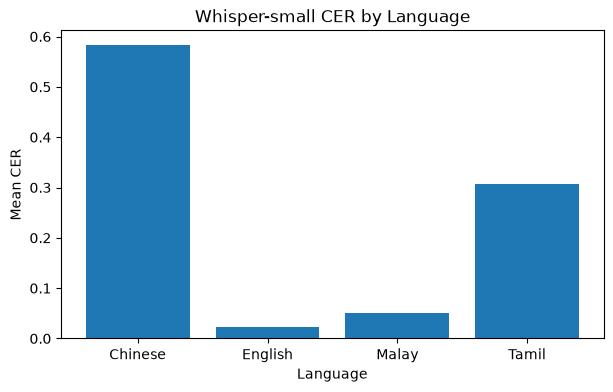

In [25]:
# bar chart for whisper small cer by language
plt.figure(figsize=(7, 4))
plt.bar(whisper_fairness["language"],whisper_fairness["CER"])
plt.xlabel("Language")
plt.ylabel("Mean CER")
plt.title("Whisper-small CER by Language")
plt.show()

In [26]:
# run garbage collection
gc.collect()
# if a GPU is available
if torch.cuda.is_available():
    torch.cuda.empty_cache()

The per-language means are directly comparable because the test set is balanced across languages, and the gap that results is a clear indicator of discrepancy. The investigation highlights that WER is unreliable for the non-space-segmented language, hence the character-level CER is used as the main fairness metric. The translation model can then be loaded after memory has been released.

## 5 NLLB Translation Language Fairness

Translation fairness in Tamil, Chinese, and Malay is audited in this area. Each language's cleaned OPUS-100 test pairs are loaded, each English source is translated into the target language using the appropriate language code by NLLB-200, and each language's chrF++ and BLEU are calculated and reduced to a best-versus-worst gap. For the same reason that it is used elsewhere, chrF++ is the main metric because it is more dependable than BLEU for these applications.

In [27]:
# set nllb model
NLLB_MODEL = ("facebook/""nllb-200-distilled-600M")

In [28]:
# define target codes
TARGET_CODES = {
    "Malay": "zsm_Latn",
    "Chinese": "zho_Hans",
    "Tamil": "tam_Taml"
}

In [29]:
# compute opus test
OPUS_TEST = (BASE_DIR / "data" / "processed" / "opus100_translation" / "testing")

In [30]:
# define translation data
translation_data = {}

In [31]:
for language in TARGET_CODES:
    # read CSV file
    translation_data[language] = pd.read_csv(OPUS_TEST / f"{language.lower()}.csv")
    print(language,len(translation_data[language]))

Malay 100
Chinese 100
Tamil 100


In [32]:
# set tokenizer
tokenizer = (AutoTokenizer.from_pretrained(NLLB_MODEL))
# compute translation model
translation_model = (AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL).to(TORCH_DEVICE))
# switch model to evaluation mode
translation_model.eval()

M2M100ForConditionalGeneration(
  (model): M2M100Model(
    (shared): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
    (encoder): M2M100Encoder(
      (embed_tokens): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
      (embed_positions): M2M100SinusoidalPositionalEmbedding()
      (layers): ModuleList(
        (0-11): 12 x M2M100EncoderLayer(
          (self_attn): M2M100Attention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=Tr

In [33]:
# define translate text
def translate_text(text,target_code):
    # tokenizer
    tokenizer.src_lang = ("eng_Latn")
    # inputs
    inputs = tokenizer(text,return_tensors="pt",truncation=True,max_length=512)
    # define inputs
    inputs = {
        key: value.to(TORCH_DEVICE)
        for key, value
        in inputs.items()
    }
    with torch.inference_mode():
        # compute generated
        generated = (translation_model.generate(**inputs,forced_bos_token_id=tokenizer.convert_tokens_to_ids(target_code),max_new_tokens=128))
    return (tokenizer.batch_decode(generated,skip_special_tokens=True)[0])

In [34]:
# define translation rows list
translation_rows = []

In [35]:
for language, data in (translation_data.items()):
    print(f"Evaluating {language}...")
    for index, row in (data.iterrows()):
        # predictions and reference
        prediction = translate_text(row["source"],TARGET_CODES[language])
        reference = normalise_text(row["reference"])
        prediction = normalise_text(prediction)
        # translation rows append to list
        translation_rows.append({
            "language": language,
            "source": row["source"],
            "reference": reference,
            "prediction": prediction
        })
        if (index + 1) % 25 == 0:
            print(language,index + 1,"/",len(data))

Evaluating Malay...
Malay 25 / 100
Malay 50 / 100
Malay 75 / 100
Malay 100 / 100
Evaluating Chinese...
Chinese 25 / 100
Chinese 50 / 100
Chinese 75 / 100
Chinese 100 / 100
Evaluating Tamil...
Tamil 25 / 100
Tamil 50 / 100
Tamil 75 / 100
Tamil 100 / 100


In [36]:
# translation predictions dataframe
translation_predictions = (pd.DataFrame(translation_rows))
translation_predictions.head()

,language,source,reference,prediction
0,Malay,"We appreciate the effort, but the point was no...",kami menghargai usaha tetapi titik itu bukan u...,kami menghargai usaha itu tetapi intinya bukan...
1,Malay,So he let us go,jadi dia biarkan kita pergi,jadi dia membiarkan kita pergi
2,Malay,And they persisted in rejecting them wrongfull...,dan mereka mengingkarinya secara zalim dan som...,dan mereka tetap mendustakannya dengan tidak b...
3,Malay,Drive home from Trenton.,pulang dari trenton,memandu pulang dari trenton
4,Malay,"Now, SpongeBob loved his job as a fry cook mor...",spongebob amat menyayangi pekerjaannya sebagai...,sekarang spongebob suka pekerjaannya sebagai s...


In [37]:
# define translation rows summary list
translation_rows_summary = []

In [38]:
for language, group in (translation_predictions.groupby("language")):
    # set predictions
    predictions = (group["prediction"].tolist())
    # set references
    references = (group["reference"].tolist())
    # compute chrf score
    chrf_score = (chrf_metric.corpus_score(predictions,[references]).score)
    # compute bleu score
    bleu_score = (bleu_metric.corpus_score(predictions,[references]).score)
    # translation rows append to the list
    translation_rows_summary.append({
        "language": language,
        "Samples": len(group),
        "chrF++": chrf_score,
        "BLEU": bleu_score
    })

In [39]:
# build dataframe for translation fairness
translation_fairness = pd.DataFrame(translation_rows_summary)
translation_fairness[["chrF++", "BLEU"]] = translation_fairness[["chrF++", "BLEU"]].round(4)
translation_fairness

,language,Samples,chrF++,BLEU
0,Chinese,100,28.6489,15.5629
1,Malay,100,43.2315,15.8900
2,Tamil,100,38.1402,28.9384


In [40]:
# compute translation chrf gap
translation_chrf_gap = (translation_fairness["chrF++"].max() - translation_fairness["chrF++"].min())
# compute translation bleu gap
translation_bleu_gap = (translation_fairness["BLEU"].max() - translation_fairness["BLEU"].min())
# compute translation best
translation_best = (translation_fairness.loc[translation_fairness["chrF++"].idxmax(),"language"])
# compute translation weakest
translation_weakest = (translation_fairness.loc[translation_fairness["chrF++"].idxmin(),"language"])

In [41]:
# print statements
print("Highest chrF++:",translation_best)
print("Lowest chrF++:",translation_weakest)
print("chrF++ gap:",round(translation_chrf_gap,4))
print("BLEU gap:",round(translation_bleu_gap,4))

Highest chrF++: Malay
Lowest chrF++: Chinese
chrF++ gap: 14.5826
BLEU gap: 13.3755


**Analysis:** 

Though not as much as Whisper, NLLB-200 also differs by language. With a chrF++ gap of 14.58 and a BLEU gap of 13.38 in the same direction, it translates into Chinese worst (chrF++ 28.65) and Malay best (chrF++ 43.23). Chinese is the language that contributes the least amount of high-quality data to these multilingual models, while Latin-script and Tamil are the languages that contribute the most, according to a consistent pattern observed in both the transcription and translation stages.

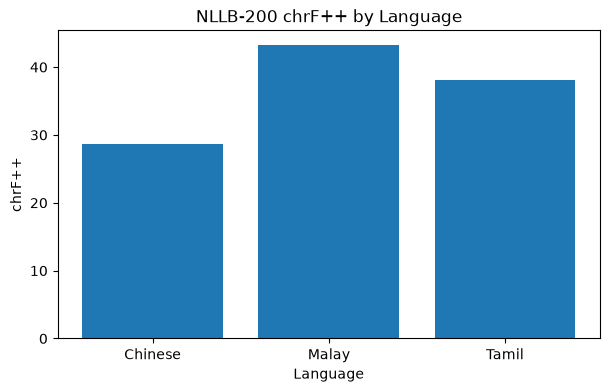

In [42]:
# bar chart for NLLB-200 chrF++ by language
plt.figure(figsize=(7, 4))
plt.bar(translation_fairness["language"],translation_fairness["chrF++"])
plt.xlabel("Language")
plt.ylabel("chrF++")
plt.title("NLLB-200 chrF++ by Language")
plt.show()

In [43]:
# run garbage collection
gc.collect()
# if a GPU is available
if torch.cuda.is_available():
    torch.cuda.empty_cache()

The audit represents actual usage rather than an abstract benchmark because translation is evaluated on the same three non-English languages that the application supports. A common pattern indicates a data-driven cause shared by both multilingual models, so determining if the translation step shows the same language ordering as the transcription stage is instructive in and of itself. Before the last part, memory is once more released.

## 6 MERaLiON Gender Fairness

The fairness of the speech-emotion model across speaker sex is audited in this section. Instead of running the model again, it takes the cached RAVDESS test predictions from the audio model-selection notebook, determines the sex of each speaker using the RAVDESS actor-numbering convention (even female, odd male), and calculates accuracy and macro-F1 independently for each group. This audit maintains full consistency with the previous assessment by reusing the stored forecasts.

In [44]:
# predictions files
prediction_files = list(BASE_DIR.rglob("selected_audio_model_test_predictions.csv"))

In [45]:
if not prediction_files:
    # raise FileNotFoundError
    raise FileNotFoundError("selected_audio_model_test_predictions.csv was not found")

In [46]:
# audio predictions
AUDIO_PREDICTIONS = max(prediction_files, key=lambda path: path.stat().st_mtime)

In [47]:
# print statements
print("Using:",AUDIO_PREDICTIONS)

Using: C:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP\Notebooks\model_experiments\outputs\audio\selected_audio_model_test_predictions.csv


In [48]:
# read CSV file
audio_predictions = pd.read_csv(AUDIO_PREDICTIONS).copy()
# compute audio predictions
audio_predictions["actor"] = (audio_predictions["actor"].astype(int))
audio_predictions["Actual Emotion"] = (audio_predictions["Actual Emotion"].astype(str).str.strip().str.lower())
audio_predictions["Predicted Emotion"] = (audio_predictions["Predicted Emotion"].astype(str).str.strip().str.lower())
audio_predictions["speaker_sex"] = (audio_predictions["actor"].apply(lambda actor:"male" if actor % 2 == 1 else "female"))
audio_predictions.head()

,actor,Actual Emotion,Predicted Emotion,speaker_sex
0,17,neutral,sadness,male
1,17,neutral,neutral,male
2,17,neutral,neutral,male
3,17,neutral,neutral,male
4,17,happiness,happiness,male


In [49]:
# define audio rows list
audio_rows = []

In [50]:
for speaker_sex, group in (audio_predictions.groupby("speaker_sex")):
    # read Actual Emotion
    y_true = group["Actual Emotion"]
    # read Predicted Emotion
    y_pred = group["Predicted Emotion"]
    # audio rows append to list
    audio_rows.append({
        "speaker_sex":speaker_sex,
        "Speakers":group["actor"].nunique(),
        "Samples":len(group),
        "Accuracy":accuracy_score(y_true,y_pred),
        "Macro Precision": precision_score(y_true,y_pred, average="macro", zero_division=0),
        "Macro Recall":recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro-F1":f1_score(y_true, y_pred, average="macro", zero_division=0)
    })

In [51]:
# audio fairness dataframe
audio_fairness_df = pd.DataFrame(audio_rows)
audio_fairness_df

,speaker_sex,Speakers,Samples,Accuracy,Macro Precision,Macro Recall,Macro-F1
0,female,4,176,0.721591,0.787703,0.718750,0.700709
1,male,4,176,0.625000,0.670947,0.630208,0.616257


**Analysis:** 

The RAVDESS actors (odd-numbered actors are male, even female) are used to assess fairness across speaker sex for the speech-emotion model. With a moderate accuracy gap of 0.0966 and macro-F1 gap of 0.0845 over four speakers of each sex, MERaLiON-SER performs better on female speakers (accuracy 0.7216, macro-F1 0.7007) than on male speakers (accuracy 0.6250, macro-F1 0.6163). Given that a mixed-sex healthcare workforce uses the application, the disparity is not insignificant in comparison to the language inequalities mentioned above, but it is still worth keeping an eye on.

In [52]:
if len(audio_fairness_df) == 2:
    # compute audio accuracy gap
    audio_accuracy_gap = (audio_fairness_df["Accuracy"].max() - audio_fairness_df["Accuracy"].min())
    # compute audio f1 gap
    audio_f1_gap = (audio_fairness_df["Macro-F1"].max() - audio_fairness_df["Macro-F1"].min())
    # gap summary dataframe
    gap_summary_df = pd.DataFrame([{
        "Metric": "Audio fairness gap",
        "Accuracy Gap": audio_accuracy_gap,
        "Macro-F1 Gap": audio_f1_gap
    }])
    gap_summary_df

A practical method of obtaining a demographic label that RAVDESS supports is to derive sex from the documented actor convention, which permits at least one demographic fairness check on the emotion channel. The study interprets the generated per-group metrics and their gap, which quantify whether the model favors one group. The fairness dimensions that could and could not be covered are listed in the next section.

## 7 Fairness Evaluation Coverage

This section provides an explicit table that details the audit's scope, including which components were examined, along which fairness dimension, and if they were assessed. It makes it clear that because their evaluation data lacks demographic labels, the text and vision models were not evaluated for demographic fairness.

In [53]:
# fairness coverage dataframe
fairness_coverage = pd.DataFrame([
    {
        "Component": "Whisper",
        "Fairness dimension":"Language",
        "Status": "Evaluated"
    },
    {
        "Component": "NLLB-200",
        "Fairness dimension": "Language",
        "Status": "Evaluated"
    },
    {
        "Component": "MERaLiON",
        "Fairness dimension": "Speaker sex",
        "Status": "Evaluated"
    },
    {
        "Component": "RoBERTa",
        "Fairness dimension": "Demographic groups",
        "Status": "Not evaluated - no demographic labels in CancerEmo"
    },
    {
        "Component": "ViT",
        "Fairness dimension": "Demographic groups",
        "Status": "Not evaluated - no demographic labels in RAF-DB evaluation files"
    }
])

In [54]:
# fairness coverage shown
fairness_coverage

,Component,Fairness dimension,Status
0,Whisper,Language,Evaluated
1,NLLB-200,Language,Evaluated
2,MERaLiON,Speaker sex,Evaluated
3,RoBERTa,Demographic groups,Not evaluated - no demographic labels in Cance...
4,ViT,Demographic groups,Not evaluated - no demographic labels in RAF-D...


**Analysis:** 

The scope of the coverage chart is purposefully truthful. Whisper and NLLB-200 are examined for language fairness, while MERaLiON is evaluated for speaker-sex fairness. The row labelled ViT refers to the vision channel, whose deployed model is DDAMFN++; neither has demographic labels in RAF-DB. However, CancerEmo and the RAF-DB evaluation files lack demographic labels, making it impossible to analyze the text (RoBERTa) and visual (facial-expression) models for demographic fairness. It's important to record these as plainly not evaluated rather than quietly leaving them out since this clarifies the actual boundaries of the fairness audit rather than suggesting that it is comprehensive.

A coverage table is a tiny but crucial component of research integrity it keeps the audit from being interpreted as being more thorough than it actually is and transforms the missing evaluations from a silent gap into a documented limitation and a clear guide for future work. All of the measured discrepancies are combined in the following section.

## 8 Fairness Gap Summary

The Whisper CER and WER gaps, the NLLB chrF++ and BLEU gaps, and the MERaLiON accuracy and macro-F1 gaps are all combined into a single summary table in this section. The gaps' relative proportions are instantly apparent when they are presented side by side.

In [55]:
# fairness summary dataframe
fairness_summary = pd.DataFrame([
    {
        "Evaluation":"Whisper language",
        "Metric": "CER",
        "Gap": whisper_cer_gap
    },
    {
        "Evaluation": "Whisper language",
        "Metric": "WER",
        "Gap": whisper_wer_gap
    },
    {
        "Evaluation": "NLLB language",
        "Metric": "chrF++",
        "Gap": translation_chrf_gap
    },
    {
        "Evaluation": "NLLB language",
        "Metric": "BLEU",
        "Gap": translation_bleu_gap
    },
    {
        "Evaluation": "MERaLiON speaker sex",
        "Metric": "Accuracy",
        "Gap": audio_accuracy_gap
    },
    {
        "Evaluation": "MERaLiON speaker sex",
        "Metric": "Macro-F1",
        "Gap": audio_f1_gap
    }
])

In [56]:
# fairness summary gap dataframe
fairness_summary["Gap"] = fairness_summary["Gap"].round(4)
# show fairness_summary
fairness_summary

,Evaluation,Metric,Gap
0,Whisper language,CER,0.5606
1,Whisper language,WER,0.9416
2,NLLB language,chrF++,14.5826
3,NLLB language,BLEU,13.3755
4,MERaLiON speaker sex,Accuracy,0.0966
5,MERaLiON speaker sex,Macro-F1,0.0845


**Analysis:** 

When gathered in one location, the gaps reveal the areas where fairness risk is concentrated: the MERaLiON speaker-sex gaps are relatively small (accuracy 0.0966, macro-F1 0.0845), but the largest and most actionable disparity is Whisper's language performance (CER gap 0.5606), followed by NLLB's translation quality (chrF++ gap 14.58). The application's language coverage for Tamil and Chinese is its weakest fairness characteristic, which should influence user expectations and any subsequent data gathering efforts. 

Three distinct audits are combined into a single view to create an overall fairness picture that quickly reveals which dimension is more risky and should be prioritised. The report uses this consolidated table as evidence, and the conclusion that follows makes it evident where the system is and is not impartial.

## 9 Conclusion

This fairness audit identifies the discrepancies and demonstrates that the Solace pipeline is not consistently impartial. The largest is language: NLLB-200 displays the same ordering in translation quality (chrF++ gap 14.58), while Whisper transcribes English and Malay far more accurately than Tamil and, particularly, Chinese (CER gap 0.5606). Although substantially reduced (accuracy gap 0.0966, macro-F1 gap 0.0845), the speaker-sex gap for the MERaLiON emotion model still favors female speakers.

These results are restricted by two sincere cautions. The character-level CER gap is a fair measure because the headline Chinese WER gap is inflated due to the poorly defined word error rate for a non-space-segmented language; additionally, the evaluation data of the text and vision models lacks demographic labels, making it impossible to audit them for demographic fairness. Instead of being concealed, both restrictions are stated.

The practical implication for the application is that language coverage, not speaker sex, is the most important fairness concern. This should be reflected in future data gathering as well as user-facing expectations for Tamil and Chinese. Building this audit into the project at all is itself a responsible-AI step, giving a concrete, reproducible baseline against which future improvements can be measured.

## 10 References

[1] S. R. Livingstone and F. A. Russo, "The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS): A dynamic, multimodal set of facial and vocal expressions in North American English," PLoS ONE, vol. 13, no. 5, Art. no. e0196391, 2018, doi: 10.1371/journal.pone.0196391.